# 01 · Did it work? (Exp3) — *each arm vs its own base*

The foundational question, answered **symmetrically for every arm**: QC → selection toggle →
outcomes / ranks / subscales → trajectories → the per-arm "beat base" battery (familiar **+**
persona-paired + Friedman) → selection sensitivity. Cross-method (PTO vs GRPO) lives in `02`;
look-ahead K in `03`; mechanism in `04`; preference in `05`.

In [1]:
import sys, os; sys.path.insert(0, os.path.abspath("."))           # cwd = eda/ -> `import exp3`
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
pd.set_option("display.width", 185, "display.max_columns", 50)
import exp3
from exp3 import stats, behavior, training, pref, figures, plots
S = exp3.notebook_setup()      # S.ARMS, S.SCORES, S.PALETTE, S.METRICS, S.ORACLE_NOISE, S.RESULTS_DIR

arms on disk: [('PTO_LA0', 11), ('PTO_LA5', 6), ('GRPO_LA0', 6), ('GRPO_LA5', 2)]
scores_long: (16128, 19) | arms scored: ['GRPO_LA0', 'GRPO_LA5', 'PTO_LA0', 'PTO_LA5']
exports -> C:\Users\baruc\Desktop\Projects\Thesis_PTO_GRPO\Exp3_PTO_GRPO\eda\results


## 0 · Quality control

In [2]:
for a in S.ARMS:
    try:
        exp3.validate_recovery(a.conv_dir, a.seed, a.iters)
    except Exception as e:
        print(f"  [QC] {a.label}: persona validation skipped ({e})")
cov = S.SCORES.groupby(["arm", "iteration", "questionnaire"]).size()
print("eval coverage per cell — min:", cov.min(), "max:", cov.max())
display(training.scan_degeneracy(training.load_generations(S.ARMS))[
    ["arm", "train_iter", "n_candidates", "pct_leak", "pct_empty", "pct_floored", "mean_score"]])

persona recovery: permutation OK for iters [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]; age-in-intro match 102/102 (100%)


persona recovery: permutation OK for iters [0, 1, 2, 3, 4, 5]; age-in-intro match 43/43 (100%)


persona recovery: permutation OK for iters [0, 1, 2, 3, 4, 5]; age-in-intro match 51/51 (100%)


persona recovery: permutation OK for iters [0, 1]; age-in-intro match 19/19 (100%)
eval coverage per cell — min: 96 max: 96


,arm,train_iter,n_candidates,pct_leak,pct_empty,pct_floored,mean_score
0,GRPO_LA0,1,14352,0.0,0.18,0.18,3.074450
1,GRPO_LA0,2,6160,0.0,0.03,0.03,3.043861
2,GRPO_LA0,3,16032,0.0,0.01,0.01,3.252195
3,GRPO_LA0,4,13440,0.0,0.00,0.00,3.662654
4,GRPO_LA0,5,15600,0.0,0.00,0.00,3.729112
5,GRPO_LA5,1,7160,0.0,0.21,0.21,2.813640
6,PTO_LA0,1,7592,0.0,0.24,0.00,3.290739
7,PTO_LA0,2,6176,0.0,0.13,0.00,3.332432
8,PTO_LA0,3,6296,0.0,0.30,0.00,3.536591
9,PTO_LA0,4,5176,0.0,0.15,0.00,3.663854


## 1 · Selection toggle

In [3]:
SELECTION = "all"          # "all" | "best_per_exp"
if SELECTION == "best_per_exp":
    SEL, best = exp3.best_per_experiment(S.SCORES); display(best)
else:
    SEL = exp3.all_models(S.SCORES); print("Showing ALL models.")
SEL_ORDER = figures.model_order(SEL); print("models in view:", SEL.model.nunique())

Showing ALL models.
models in view: 24


## 2 · Outcome comparison — bars + rankings

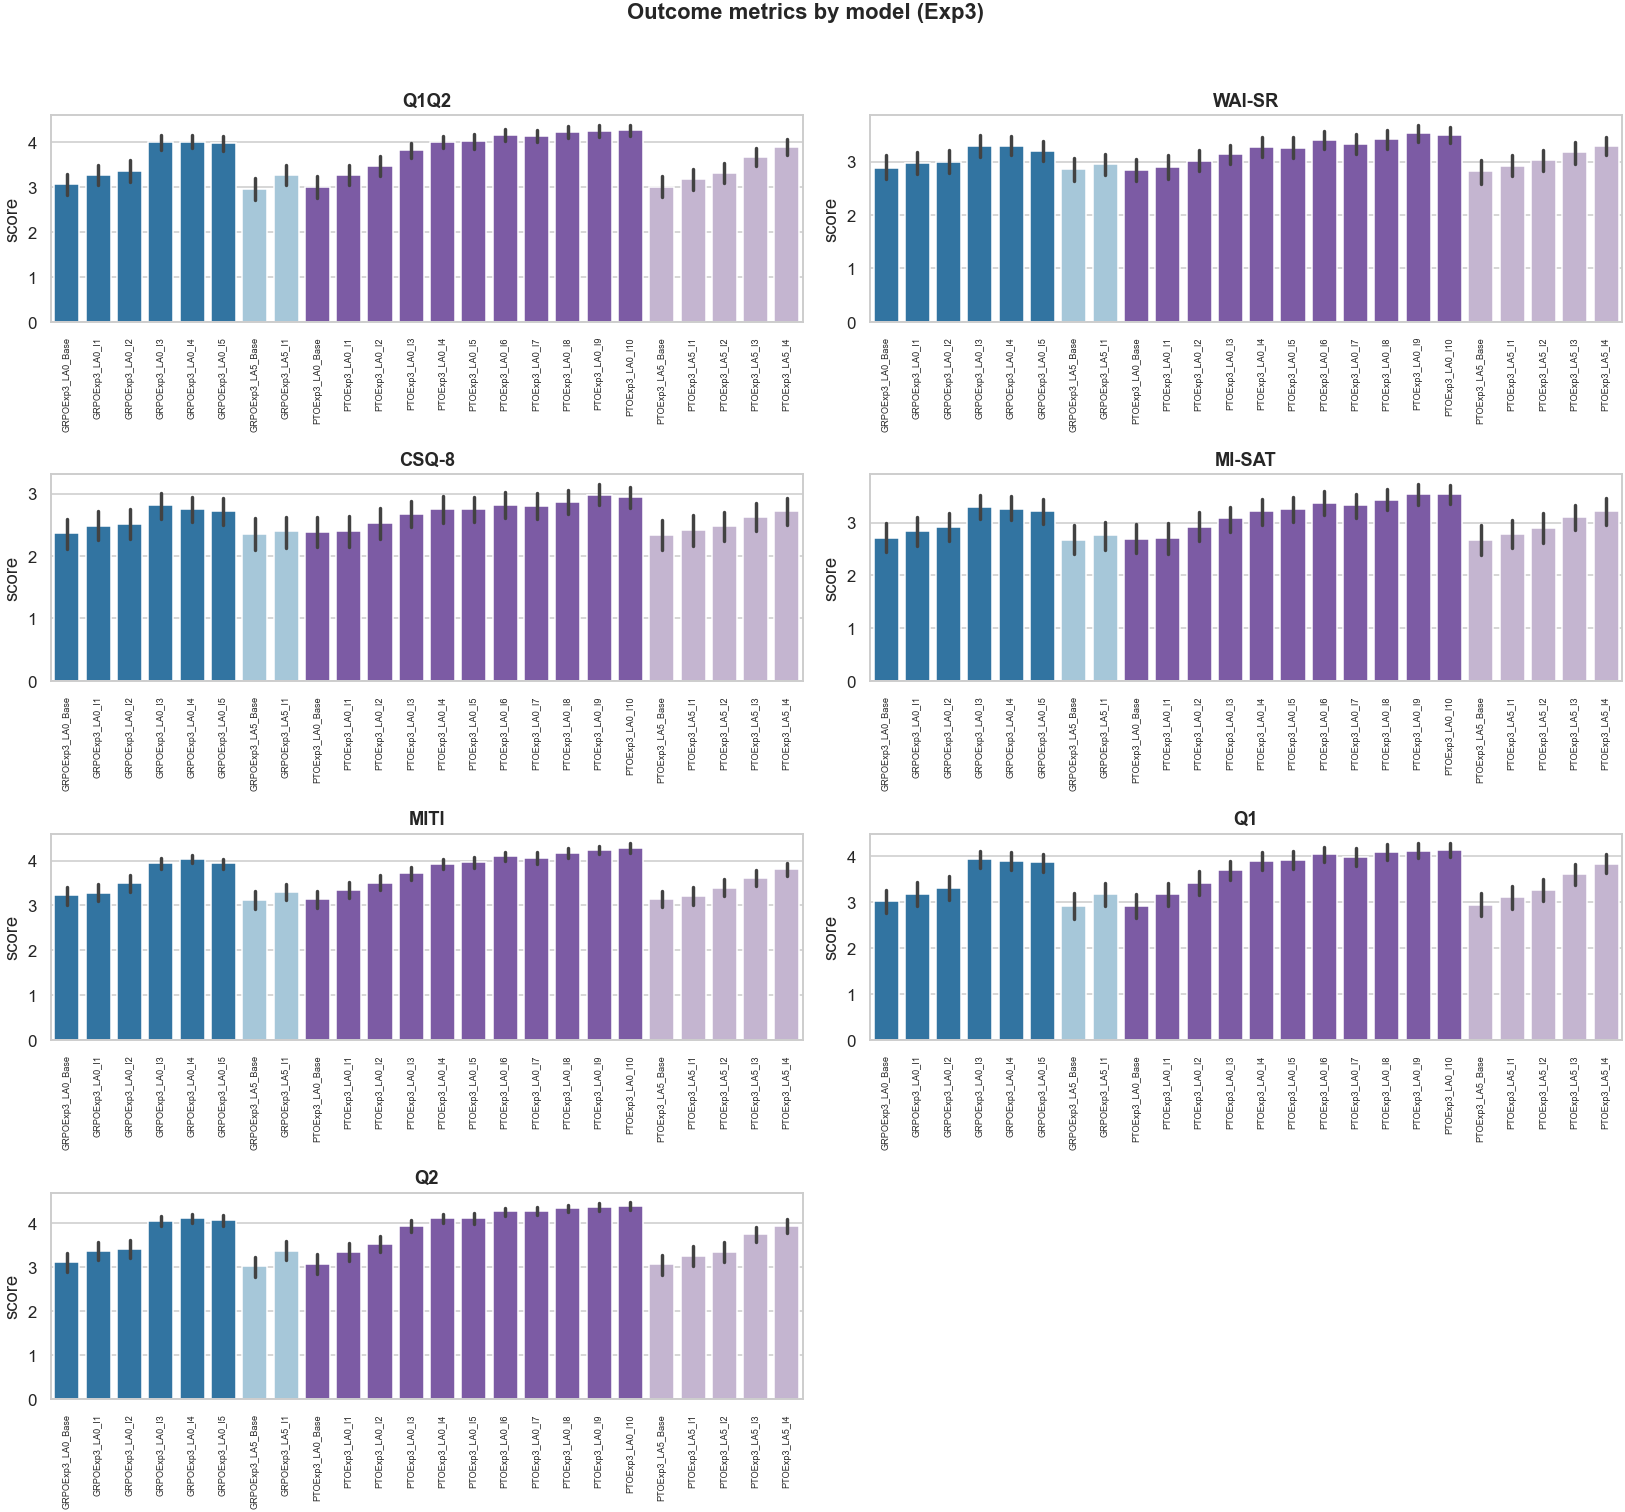

,arm,iteration,is_base,Q1Q2,WAI-SR,CSQ-8,MI-SAT,MITI,Q1,Q2,rank_Q1Q2,rank_WAI-SR,rank_CSQ-8,rank_MI-SAT,rank_MITI,rank_Q1,rank_Q2,AvgRank
model,,,,,,,,,,,,,,,,,,
PTOExp3_LA0_I10,PTO_LA0,10,False,4.260,3.497,2.945,3.536,4.273,4.140,4.380,1.0,2.0,2.0,2.0,1.0,1.0,1.0,1.429
PTOExp3_LA0_I9,PTO_LA0,9,False,4.238,3.536,2.980,3.540,4.242,4.121,4.356,2.0,1.0,1.0,1.0,2.0,2.0,2.0,1.571
PTOExp3_LA0_I8,PTO_LA0,8,False,4.221,3.424,2.865,3.429,4.172,4.100,4.341,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.000
PTOExp3_LA0_I6,PTO_LA0,6,False,4.154,3.406,2.816,3.368,4.091,4.044,4.264,4.0,4.0,4.0,4.0,4.0,4.0,5.0,4.143
PTOExp3_LA0_I7,PTO_LA0,7,False,4.129,3.326,2.801,3.328,4.068,3.975,4.283,5.0,5.0,6.0,5.0,5.0,5.0,4.0,5.000
GRPOExp3_LA0_I3,GRPO_LA0,3,False,3.993,3.301,2.811,3.290,3.938,3.935,4.051,9.0,6.0,5.0,6.0,9.0,6.0,10.0,7.286
GRPOExp3_LA0_I4,GRPO_LA0,4,False,4.004,3.292,2.751,3.266,4.039,3.898,4.111,8.0,8.0,7.0,7.0,6.0,9.0,7.0,7.429
PTOExp3_LA0_I5,PTO_LA0,5,False,4.014,3.264,2.749,3.262,3.961,3.923,4.106,6.0,10.0,9.0,8.0,7.0,7.0,8.0,7.857
PTOExp3_LA0_I4,PTO_LA0,4,False,4.008,3.280,2.751,3.210,3.924,3.900,4.115,7.0,9.0,7.0,11.0,10.0,8.0,6.0,8.286


'C:\\Users\\baruc\\Desktop\\Projects\\Thesis_PTO_GRPO\\Exp3_PTO_GRPO\\eda\\results\\tables'

In [4]:
fig = plots.outcomes_by_model(SEL, palette=S.PALETTE, order=SEL_ORDER)
exp3.save_fig(fig, "outcomes_by_model", caption="All models, rubrics; mean +/- 95% CI over 96 personas."); plt.show()
RANK = stats.rank_table(SEL).round(3); display(RANK)
exp3.save_table(RANK.reset_index(), "model_rankings", caption="Per-rubric rank (1=best) + average rank per model.")

## 3 · Subscales (WAI-SR Goal/Task/Bond + MITI globals)

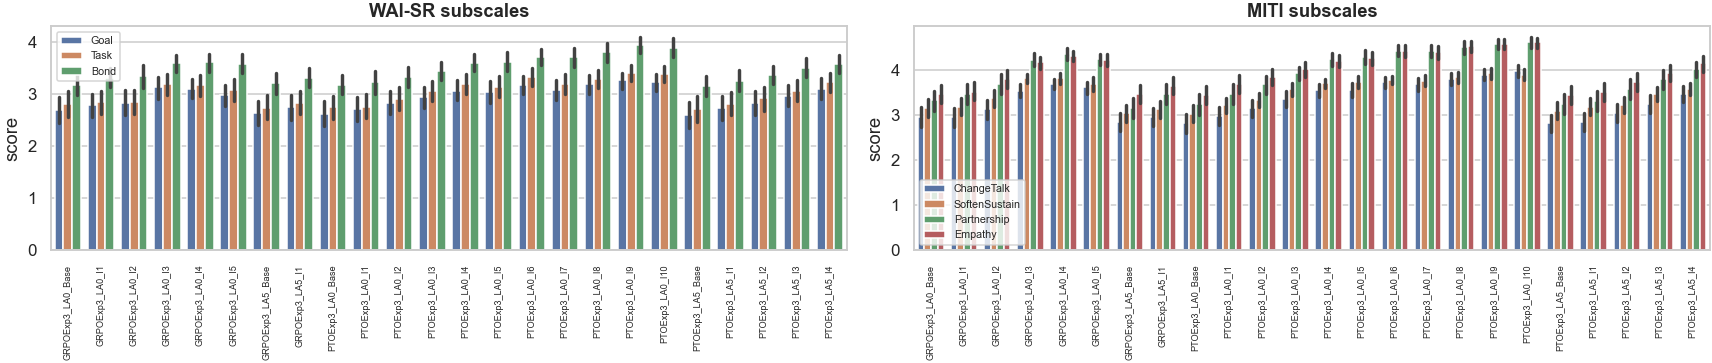

In [5]:
SUB = exp3.load_subscales(S.ARMS); SUB = SUB[SUB.model.isin(SEL.model.unique())]
fig = plots.subscales_by_model(SUB, order=SEL_ORDER)
exp3.save_fig(fig, "subscales_WAI_MITI", caption="WAI-SR (Goal/Task/Bond) + MITI global subscales by model; mean +/- 95% CI."); plt.show()

## 4 · Per-iteration trajectories

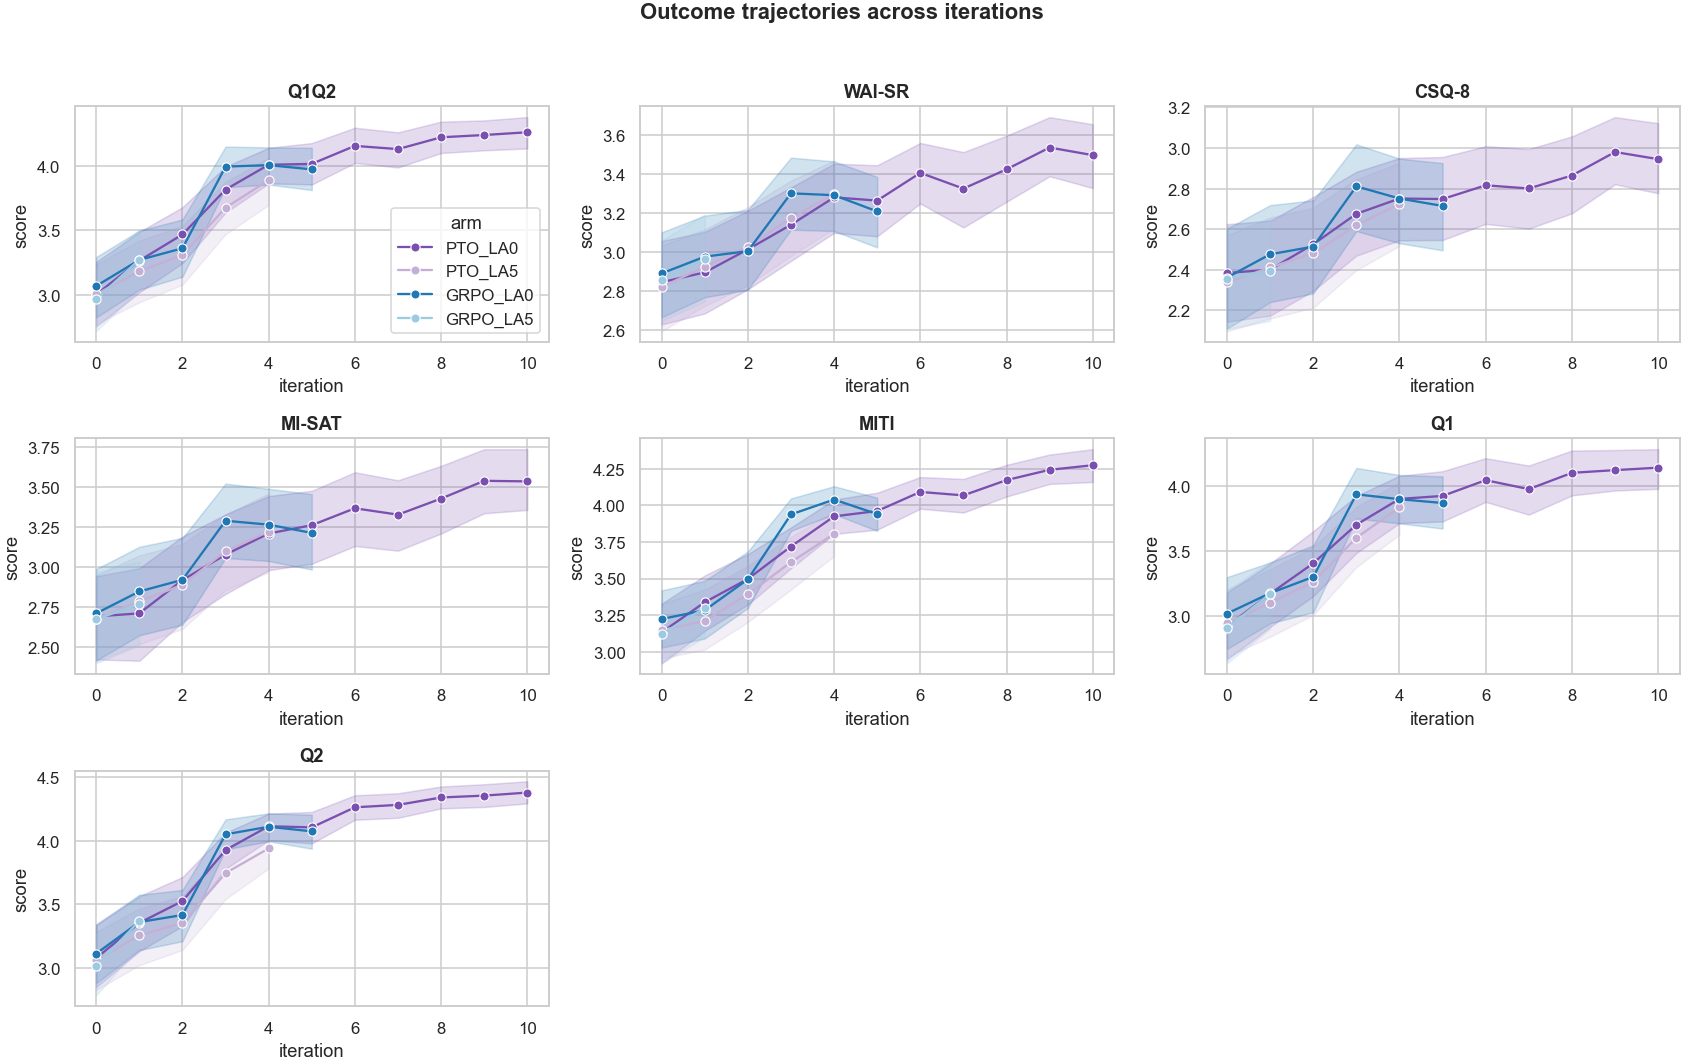

In [6]:
fig = plots.trajectory_grid(S.SCORES, palette=S.PALETTE)
exp3.save_fig(fig, "trajectories_all_rubrics", caption="Per-rubric mean +/- 95% CI across iterations, arms overlaid."); plt.show()

## 5 · Per-arm "beat base" battery (every arm)
For each arm: Friedman omnibus (all rubrics) + the persona-paired Q1+Q2 vs-base table. Trimmed view
inline; the full table is exported. Thin arms (<2 trained iters) are skipped.

In [7]:
for arm in sorted(S.SCORES.arm.unique()):
    a = S.SCORES[S.SCORES.arm == arm]
    if a.iteration.nunique() < 2 or not a.is_base.any():
        print(f"--- {arm}: too thin for vs-base battery (skipped) ---"); continue
    print(f"\n################  {arm}  ################")
    FR = pd.DataFrame([stats.friedman_trajectory(S.SCORES, arm, m) for m in S.METRICS])
    print("Friedman omnibus:"); display(FR[["metric", "chi2", "p", "kendall_w", "k_iters"]].round(4))
    PV = stats.paired_vs_base(S.SCORES, arm, "Q1Q2")
    if not PV.empty:
        print("Q1+Q2 vs base (persona-paired):")
        display(PV[["iteration", "mean_delta", "dz", "p_holm"]].round(4))
        exp3.save_table(PV[["iteration", "n", "mean_delta", "dz", "p", "p_holm", "ci_low", "ci_high"]].round(4),
                        f"{arm}_Q1Q2_vs_base_paired",
                        caption=f"{arm} each iteration vs base on Q1+Q2; persona-paired Wilcoxon, dz, Holm p, bootstrap 95% CI.")


################  GRPO_LA0  ################
Friedman omnibus:


,metric,chi2,p,kendall_w,k_iters
0,Q1Q2,200.1633,0.0,0.4170,6
1,WAI-SR,57.4288,0.0,0.1196,6
2,CSQ-8,67.8660,0.0,0.1414,6
3,MI-SAT,60.9824,0.0,0.1270,6
4,MITI,170.6406,0.0,0.3555,6
5,Q1,186.3109,0.0,0.3881,6
6,Q2,181.7290,0.0,0.3786,6


Q1+Q2 vs base (persona-paired):


,iteration,mean_delta,dz,p_holm
0,1,0.2022,0.2129,0.0423
1,2,0.2926,0.3341,0.0013
2,3,0.9267,1.1494,0.0000
3,4,0.9376,1.1403,0.0000
4,5,0.9050,1.1238,0.0000



################  GRPO_LA5  ################
Friedman omnibus:


...

,iteration,mean_delta,dz,p_holm
0,1,0.2632,0.2690,0.0352
1,2,0.4659,0.4587,0.0000
2,3,0.8145,0.8427,0.0000
3,4,1.0072,1.0782,0.0000
4,5,1.0141,1.0532,0.0000
5,6,1.1536,1.2035,0.0000
6,7,1.1287,1.1216,0.0000
7,8,1.2203,1.2504,0.0000
8,9,1.2381,1.3100,0.0000
9,10,1.2594,1.4288,0.0000



################  PTO_LA5  ################
Friedman omnibus:


,metric,chi2,p,kendall_w,k_iters
0,Q1Q2,91.1019,0.0,0.2372,5
1,WAI-SR,49.4226,0.0,0.1287,5
2,CSQ-8,27.9575,0.0,0.0728,5
3,MI-SAT,37.1670,0.0,0.0968,5
4,MITI,68.9866,0.0,0.1797,5
5,Q1,85.8684,0.0,0.2236,5
6,Q2,99.9496,0.0,0.2603,5


Q1+Q2 vs base (persona-paired):


,iteration,mean_delta,dz,p_holm
0,1,0.1775,0.1629,0.1293
1,2,0.3048,0.2750,0.0369
2,3,0.6710,0.6714,0.0000
3,4,0.8847,0.8811,0.0000


## 6 · Robustness — selection sensitivity (final vs best target)

In [8]:
mr_final = stats.main_results_table(S.SCORES, target="final")
mr_best  = stats.main_results_table(S.SCORES, target="best")
cols = ["rubric", "target_iter", "delta", "dz", "effect", "p_holm"]
for arm in sorted(S.SCORES.arm.unique()):
    f = mr_final[mr_final.arm == arm][cols]
    if f.empty: continue
    b = mr_best[mr_best.arm == arm][cols]
    print(f"\n=== {arm}: target=FINAL vs target=BEST ==="); print("final:"); display(f); print("best:"); display(b)
print(">> conclusions stable if effect sizes stay large & p_holm significant under both targets.")


=== GRPO_LA0: target=FINAL vs target=BEST ===
final:


,rubric,target_iter,delta,dz,effect,p_holm
0,Q1Q2,5,0.905,1.124,large,0.0
1,WAI-SR,5,0.319,0.492,small,0.0
2,CSQ-8,5,0.353,0.604,medium,0.0
3,MI-SAT,5,0.503,0.604,medium,0.0
4,MITI,5,0.716,0.979,large,0.0
5,Q1,5,0.848,1.048,large,0.0
6,Q2,5,0.962,1.097,large,0.0


best:


,rubric,target_iter,delta,dz,effect,p_holm
0,Q1Q2,4,0.938,1.140,large,0.0
1,WAI-SR,4,0.402,0.633,medium,0.0
2,CSQ-8,4,0.389,0.657,medium,0.0
3,MI-SAT,4,0.556,0.654,medium,0.0
4,MITI,4,0.815,1.047,large,0.0
5,Q1,4,0.877,1.070,large,0.0
6,Q2,4,0.998,1.112,large,0.0



=== GRPO_LA5: target=FINAL vs target=BEST ===
final:


...


=== PTO_LA5: target=FINAL vs target=BEST ===
final:


,rubric,target_iter,delta,dz,effect,p_holm
21,Q1Q2,4,0.885,0.881,large,0.0
22,WAI-SR,4,0.479,0.583,medium,0.0
23,CSQ-8,4,0.387,0.497,small,0.0
24,MI-SAT,4,0.547,0.494,small,0.0
25,MITI,4,0.656,0.756,medium,0.0
26,Q1,4,0.890,0.849,large,0.0
27,Q2,4,0.880,0.840,large,0.0


best:


,rubric,target_iter,delta,dz,effect,p_holm
21,Q1Q2,4,0.885,0.881,large,0.0
22,WAI-SR,4,0.479,0.583,medium,0.0
23,CSQ-8,4,0.387,0.497,small,0.0
24,MI-SAT,4,0.547,0.494,small,0.0
25,MITI,4,0.656,0.756,medium,0.0
26,Q1,4,0.890,0.849,large,0.0
27,Q2,4,0.880,0.840,large,0.0


>> conclusions stable if effect sizes stay large & p_holm significant under both targets.


## 7 · Takeaways
- Each trained arm is compared to **its own base** under the matched-persona design — read the dz +
  Holm-p columns of `main_results_final` for the headline effect sizes.
- The **Friedman** omnibus (Kendall's W) confirms iteration is a real within-persona factor, not noise.
- Robustness: conclusions hold if the effect stays *large* under both `final` and `best` targets.
- _(Cross-method winner → `02`; K effect → `03`.)_